# Cosmology with Cosmopower-JAX

In this notebook, we will run a chain using `BlackJAX` - a library to run inference chains with JAX.

In [ ]:
import jax
from jax import numpy as jnp
from jax import scipy as jsc
from jax import random as jrd

import numpy as np
import matplotlib.pyplot as plt

import camb

import sys
sys.path.insert(0, "../")

import mflike_jax

import pprint

try:
    from tqdm.notebook import tqdm
except:
    tqdm = lambda x: x

**Cosmopower**

Because CAMB is not differentiable, we will need to use `cosmopower` emulators to create differentiable cosmologies.

We use the [cosmopower-jax](https://github.com/dpiras/cosmopower-jax) implementation of cosmopower.

Unfortunately, the emulators which are accurate enough for ACT analysis are not compatible with cosmopower-jax, so we will have to manually load them into a different version of cosmopower and then translate them into cosmopower-jax.

In [2]:
!git clone https://github.com/cosmopower-organization/jense_2024_emulators.git

fatal: destination path 'jense_2024_emulators' already exists and is not an empty directory.


In [3]:
# We need to cheat and install a custom branch of cosmopower
!git clone https://github.com/HTJense/cosmopower

fatal: destination path 'cosmopower' already exists and is not an empty directory.


In [4]:
import sys

sys.path.insert(0, "cosmopower")

import cosmopower as cp
from cosmopower_jax.cosmopower_jax import CosmoPowerJAX

I0000 00:00:1786101222.800893   37025 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786101225.541151   37025 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [5]:
parser = cp.YAMLParser("jense_2024_emulators/jense_2023_cmb_camb_lcdm.yaml", root_dir="jense_2024_emulators")
emulators = parser.restore_networks()

Failed to restore network derived: Failed to restore network from jense_2024_emulators/jense_2023_camb_lcdm/networks/jense_2023_camb_lcdm_derived:  does not exist..


E0000 00:00:1786101227.339856   37025 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1786101227.340265   37113 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1786101227.362237   37025 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Failed to restore network Hubble: Failed to restore network from jense_2024_emulators/jense_2023_camb_lcdm/networks/jense_2023_camb_lcdm_Hubble:  does not exist..
Failed to restore network angular_diameter_distance: Failed to restore network from jense_2024_emulators/jense_2023_camb_lcdm/networks/jense_2023_camb_lcdm_angular_diameter_distance:  does not exist..


In [6]:
# I apologize for this code,
# But the high-accuracy emulators created for cosmopower are not compatible with cosmopower-jax
# So we have to manually convert them into the right format.......
cmb_tt = CosmoPowerJAX("cmb_tt")
cmb_tt.n_parameters = emulators["Cl/tt"].n_parameters
cmb_tt.parameters = [str(x) for x in emulators["Cl/tt"].parameters]
cmb_tt.param_train_mean = emulators["Cl/tt"].parameters_mean.numpy()
cmb_tt.param_train_std = emulators["Cl/tt"].parameters_std.numpy()
cmb_tt.feature_train_mean = emulators["Cl/tt"].features_mean.numpy()
cmb_tt.feature_train_std = emulators["Cl/tt"].features_std.numpy()
cmb_tt.modes = emulators["Cl/tt"].modes

weights = [ w.numpy().T for w in emulators["Cl/tt"].W ]
biases = [ b.numpy() for b in emulators["Cl/tt"].b ]
alphas = [ a.numpy() for a in emulators["Cl/tt"].alphas ]
betas = [ b.numpy() for b in emulators["Cl/tt"].betas ]

cmb_tt.weights = list(zip(weights, biases))
cmb_tt.hyper_params = list(zip(alphas, betas))


cmb_te = CosmoPowerJAX("cmb_te")
cmb_te.n_parameters = emulators["Cl/te"].n_parameters
cmb_te.parameters = [str(x) for x in emulators["Cl/te"].parameters]
cmb_te.n_pcas = emulators["Cl/te"].n_pcas
cmb_te.pca_matrix = emulators["Cl/te"].pca_transform_matrix_
cmb_te.param_train_mean = emulators["Cl/te"].parameters_mean_
cmb_te.param_train_std = emulators["Cl/te"].parameters_std_
cmb_te.feature_train_mean = emulators["Cl/te"].pca_mean_
cmb_te.feature_train_std = emulators["Cl/te"].pca_std_
cmb_te.training_mean = emulators["Cl/te"].features_mean_
cmb_te.training_std = emulators["Cl/te"].features_std_
cmb_te.modes = emulators["Cl/te"].modes

weights = [ w.numpy().T for w in emulators["Cl/te"].W ]
biases = [ b.numpy() for b in emulators["Cl/te"].b ]
alphas = [ a.numpy() for a in emulators["Cl/te"].alphas ]
betas = [ b.numpy() for b in emulators["Cl/te"].betas ]

cmb_te.weights = list(zip(weights, biases))
cmb_te.hyper_params = list(zip(alphas, betas))


cmb_ee = CosmoPowerJAX("cmb_ee")
cmb_ee.n_parameters = emulators["Cl/ee"].n_parameters
cmb_ee.parameters = [str(x) for x in emulators["Cl/ee"].parameters]
cmb_ee.param_train_mean = emulators["Cl/ee"].parameters_mean.numpy()
cmb_ee.param_train_std = emulators["Cl/ee"].parameters_std.numpy()
cmb_ee.feature_train_mean = emulators["Cl/ee"].features_mean.numpy()
cmb_ee.feature_train_std = emulators["Cl/ee"].features_std.numpy()
cmb_ee.modes = emulators["Cl/ee"].modes

weights = [ w.numpy().T for w in emulators["Cl/ee"].W ]
biases = [ b.numpy() for b in emulators["Cl/ee"].b ]
alphas = [ a.numpy() for a in emulators["Cl/ee"].alphas ]
betas = [ b.numpy() for b in emulators["Cl/ee"].betas ]

cmb_ee.weights = list(zip(weights, biases))
cmb_ee.hyper_params = list(zip(alphas, betas))

In [7]:
ls = cmb_tt.modes
print(cmb_tt.parameters)
theta = jnp.array([ 0.022, 0.117, 3.044, 0.06, 0.96, 0.67 ])
# The emulators are given in dimensionless units, so we need to multiply by the CMB temperature (in uK^2).
T_CMB = 2.72548e6
cl_tt = cmb_tt.predict(theta) * (T_CMB ** 2.)
cl_te = cmb_te.predict(theta) * (T_CMB ** 2.)
cl_ee = cmb_ee.predict(theta) * (T_CMB ** 2.)

['ombh2', 'omch2', 'logA', 'tau', 'ns', 'h']


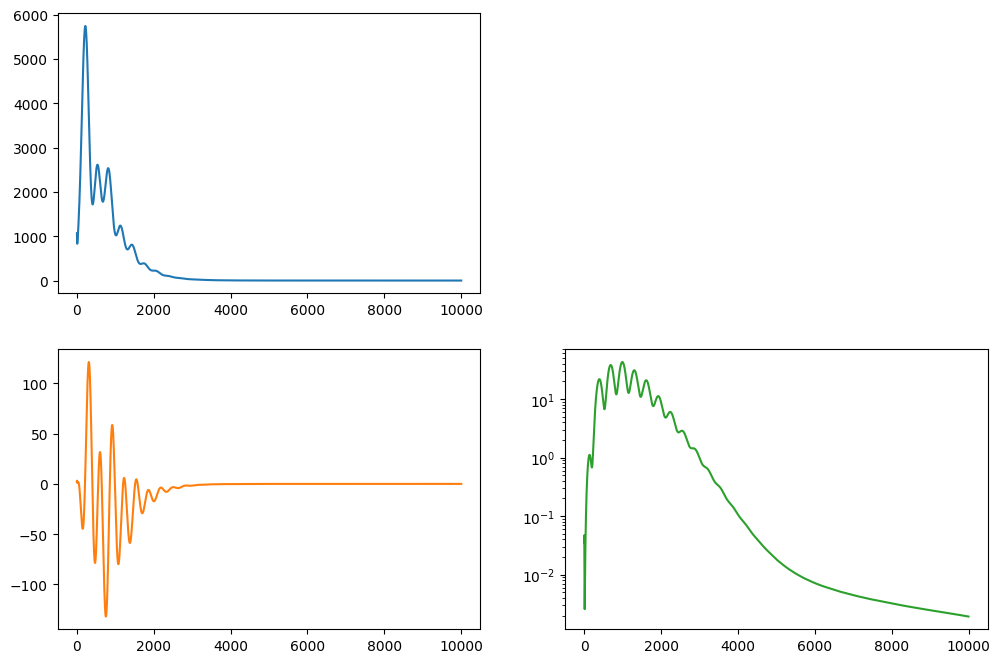

In [8]:
fig, axes = plt.subplots(2, 2, figsize = (12, 8))

fig.delaxes(axes[0,1])

ax = axes[0,0]
ax.plot(ls, cl_tt, c="C0")

ax = axes[1,0]
ax.plot(ls, cl_te, c="C1")

ax = axes[1,1]
ax.plot(ls, cl_ee, c="C2")
ax.semilogy();

In [9]:
like = mflike_jax.MFLike_jax("../act_dr6.yaml")
fg_model = mflike_jax.BandpowerForegrounds("../act_dr6_foregrounds.yaml", like)

Assuming data rows are in the correct order as it was before version 1.0.


In [10]:
# Some of our parameters have external priors, for example map-level calibration priors.
# We define these here:
priors = {
    "calG_all": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.003),

    "cal_dr6_pa4_f220": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.013),
    "cal_dr6_pa5_f090": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.0016),
    "cal_dr6_pa5_f150": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.0020),
    "cal_dr6_pa6_f090": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.0018),
    "cal_dr6_pa6_f150": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.0024),

    "bandint_shift_dr6_pa4_f220": lambda x: jsc.stats.norm.logpdf(x, loc=0.0, scale=3.6),
    "bandint_shift_dr6_pa5_f090": lambda x: jsc.stats.norm.logpdf(x, loc=0.0, scale=1.0),
    "bandint_shift_dr6_pa5_f150": lambda x: jsc.stats.norm.logpdf(x, loc=0.0, scale=1.3),
    "bandint_shift_dr6_pa6_f090": lambda x: jsc.stats.norm.logpdf(x, loc=0.0, scale=1.2),
    "bandint_shift_dr6_pa6_f150": lambda x: jsc.stats.norm.logpdf(x, loc=0.0, scale=1.1),

    "a_gtt": lambda x: jsc.stats.norm.logpdf(x, loc=7.95, scale=0.32),
    "a_gte": lambda x: jsc.stats.norm.logpdf(x, loc=0.432, scale=0.03),
    "a_gee": lambda x: jsc.stats.norm.logpdf(x, loc=0.1681, scale=0.017),

    "tau": lambda x: jsc.stats.norm.logpdf(x, loc=0.06, scale=0.01),
}

In [11]:
parameters = cmb_tt.parameters + like.parameters + fg_model.parameters

@jax.jit
def cmb_spectra(theta):
    spec_tt = jnp.concatenate([ jnp.array([0.,0.]), cmb_tt.predict(theta) * (T_CMB ** 2.) ])
    spec_te = jnp.concatenate([ jnp.array([0.,0.]), cmb_te.predict(theta) * (T_CMB ** 2.) ])
    spec_ee = jnp.concatenate([ jnp.array([0.,0.]), cmb_ee.predict(theta) * (T_CMB ** 2.) ])

    return spec_tt, spec_te, spec_ee

@jax.jit
def logpost(theta):
    # First, we need a prior contribution.
    # We use the list of named parameters defined above to find the index of each parameter in the vector.
    logprior = jnp.sum(jnp.array([
        priors[p](theta[parameters.index(p)]) for p in priors
    ]))

    # We need to split the parameter vectors into the likelihood and foreground parts.
    theta_cmb = theta[:len(cmb_tt.parameters)]
    theta_like = theta[len(cmb_tt.parameters):len(cmb_tt.parameters)+len(like.parameters)]
    theta_fg = theta[len(cmb_tt.parameters)+len(like.parameters):]

    # Then we need a likelihood contribution.
    cl_tt, cl_te, cl_ee = cmb_spectra(theta_cmb)
    foregrounds = fg_model.get_foreground_model(theta_fg)
    loglike = -0.5 * like.chisquare(cl_tt, cl_te, cl_ee, foregrounds, theta_like)

    return logprior + loglike

In [12]:
parameter_values = {
    "ombh2": 0.022,
    "omch2": 0.117,
    "h": 0.67,
    "logA": 3.05,
    "ns": 0.97,
    "tau": 0.06,

    "a_tSZ": 3.4,
    "alpha_tSZ": -0.5,
    "a_kSZ": 1.5,
    "a_c": 3.7,
    "a_p": 7.7,
    "beta_cib": 1.9,
    "xi": 0.1,
    "a_s": 2.8,
    "beta_s": -2.8,
    "a_pste": -0.025,
    "a_psee": 0.02,

    "a_gtt": 7.95,
    "a_gte": 0.423,
    "a_gee": 0.1681,

    "alpha_dT": -0.6,
    "alpha_dE": -0.4,
    "alpha_s": 1.0,
    "T_effd": 19.6,
    "T_d": 9.7,
    "beta_d": 1.5,
    "alpha_p": 1.0,
    "alpha_c": 0.8,

    "calG_all": 1.0,

    "cal_dr6_pa4_f220": 0.98,
    "cal_dr6_pa5_f090": 1.0,
    "cal_dr6_pa5_f150": 1.0,
    "cal_dr6_pa6_f090": 1.0,
    "cal_dr6_pa6_f150": 1.0,

    "calE_dr6_pa4_f220": 1.0,
    "calE_dr6_pa5_f090": 0.985,
    "calE_dr6_pa5_f150": 0.995,
    "calE_dr6_pa6_f090": 1.00,
    "calE_dr6_pa6_f150": 0.995,

    "bandint_shift_dr6_pa4_f220": 5.0,
    "bandint_shift_dr6_pa5_f090": 0.0,
    "bandint_shift_dr6_pa5_f150": -1.0,
    "bandint_shift_dr6_pa6_f090": 1.0,
    "bandint_shift_dr6_pa6_f150": 0.0,
}

In [13]:
parameters_baseline = [
    "ombh2", "omch2", "h", "logA", "tau", "ns",
    "a_tSZ", "a_kSZ", "alpha_tSZ", "xi", "a_c", "a_p", "beta_cib", "a_s", "beta_s",
    "a_gtt", "a_gte", "a_gee", "a_pste", "a_psee",
    "calG_all", "cal_dr6_pa4_f220", "cal_dr6_pa5_f090", "cal_dr6_pa5_f150", "cal_dr6_pa6_f090", "cal_dr6_pa6_f150",
    "calE_dr6_pa5_f090", "calE_dr6_pa5_f150", "calE_dr6_pa6_f090", "calE_dr6_pa6_f150",
    "bandint_shift_dr6_pa4_f220", "bandint_shift_dr6_pa5_f090", "bandint_shift_dr6_pa5_f150", "bandint_shift_dr6_pa6_f090", "bandint_shift_dr6_pa6_f150",
]

# We need a log-posterior function that only takes in X parameters and keeps the remainder fixed.
def model_logpost(param_names):
    fit_idx = jnp.array([ parameters.index(p) for p in param_names ])
    theta_default = jnp.array([ parameter_values[p] for p in parameters ])

    def restricted_logpost(theta_x):
        theta = theta_default.at[fit_idx].set(theta_x)
        return logpost(theta)

    return jax.jit(restricted_logpost)

logpost_baseline = model_logpost(parameters_baseline)
theta_baseline = jnp.array([ parameter_values[p] for p in parameters_baseline ])

logpost_grad = jax.jit(jax.grad(logpost_baseline))
logpost_hess = jax.jit(jax.hessian(logpost_baseline))

In [14]:
# The sampler we are going to use is designed to work on N(0,1) parameters.
# We can normalize the parameters around our starting point,
mean_baseline = theta_baseline.copy()
cov_baseline = jnp.linalg.inv(-logpost_hess(mean_baseline))
# The absolute value is because the Hessian might not be positive semi-definite.
# (i.e. we're not at best-fit, so we might be in a saddle point).
err_baseline = jnp.sqrt(jnp.abs(jnp.diag(cov_baseline)))

@jax.jit
def params_to_norm(theta):
    return (theta - mean_baseline) * err_baseline

@jax.jit
def norm_to_params(theta):
    return err_baseline * theta + mean_baseline

# This is the function that runs the inference chain
def inference_loop(rng, kernel, initial_state, num_samples):
    @jax.jit
    def one_step(state, rng):
        state, _ = kernel(rng, state)
        return state, state

    keys = jrd.split(rng, num_samples)
    _, states = jax.lax.scan(one_step, initial_state, keys)
    return states

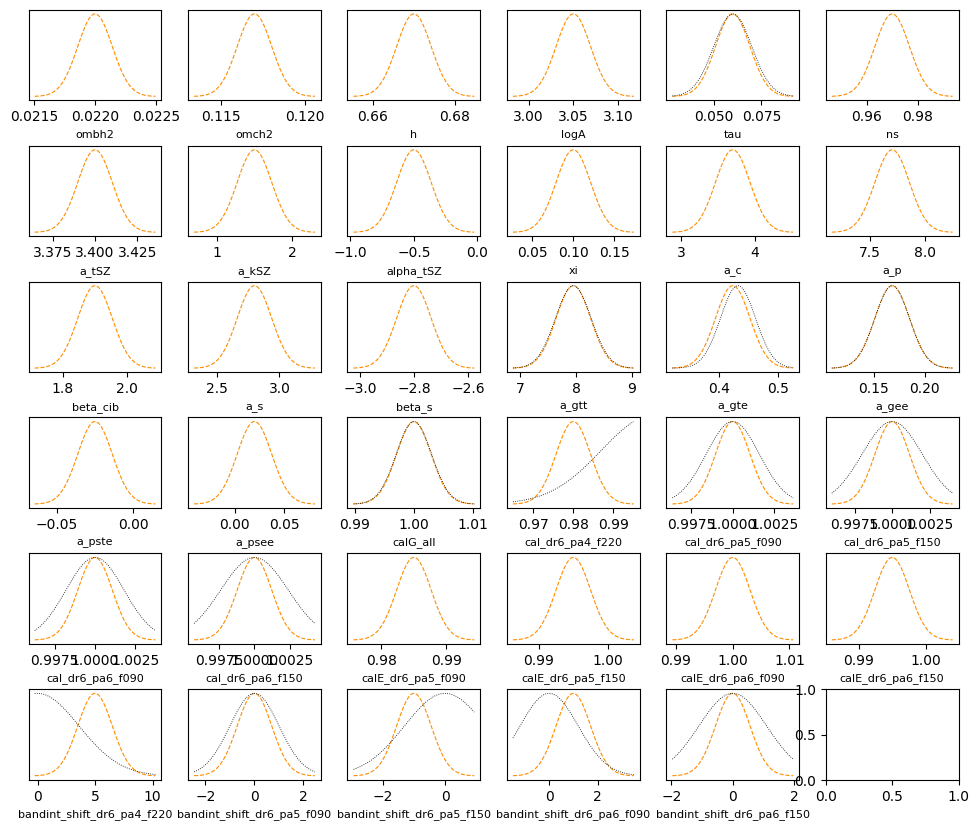

In [15]:
# Fisher forecast.
fig, axes = plt.subplots(6, 6, figsize=(12, 10), gridspec_kw={"hspace": 0.5})

for i, (par, ax) in enumerate(zip(parameters_baseline, axes.flatten())):
    m = mean_baseline[i]
    s = err_baseline[i]

    x = np.linspace(m - 3.5*s, m+3.5*s, 100)
    y = np.exp(-0.5 * np.power((x - m) / s, 2.))
    ax.plot(x, y, c="darkorange", lw=0.8, ls="--")
    ax.set_xlabel(par, fontsize=8)

    if par in priors:
        y = np.exp(priors[par](x))
        ax.plot(x, y / y.max(), c="k", lw=0.6, ls=":")
    
    ax.set_yticks([])

In [16]:
import datetime
import blackjax

# Run the full chain using a Hamiltonian Monte-Carlo (HMC) or No U-Turn Sampler (NUTS).
# !! This whole cell can take a while to evaluate !!

# Map the normalized parameters back to physical parameters.
logpost_norm = lambda theta_norm: logpost_baseline(norm_to_params(theta_norm))

# Use today's date as a random number.
rng = jrd.key(int(datetime.date.today().strftime("%Y%m%d")))

# If you wanted to try out a different algorithm - you only have to create a different instance here.
#nuts = blackjax.nuts(logpost_norm, step_size=0.1, inverse_mass_matrix=jnp.eye(len(theta_baseline)))
#initial_state = nuts.init(jnp.zeros(len(theta_baseline)))

# Here we will just use the HMC sampler.
hmc = blackjax.hmc(logpost_norm, step_size=0.1, inverse_mass_matrix=jnp.eye(len(theta_baseline)), num_integration_steps=5)
initial_state = hmc.init(jnp.zeros(len(theta_baseline)))

states = inference_loop(rng, jax.jit(hmc.step), initial_state, 1000)

# Extract the samples and convert them back into physical units.
samples = jax.vmap(norm_to_params)(states.position)
samples = np.array(samples)

# We can also compute the log-posterior of the samples.
logpost_samples = np.array(jax.vmap(logpost_baseline)(samples))

In [17]:
from getdist import plots
from getdist.mcsamples import MCSamples

chain = MCSamples(samples=samples, names=parameters_baseline, loglikes=-logpost_samples)

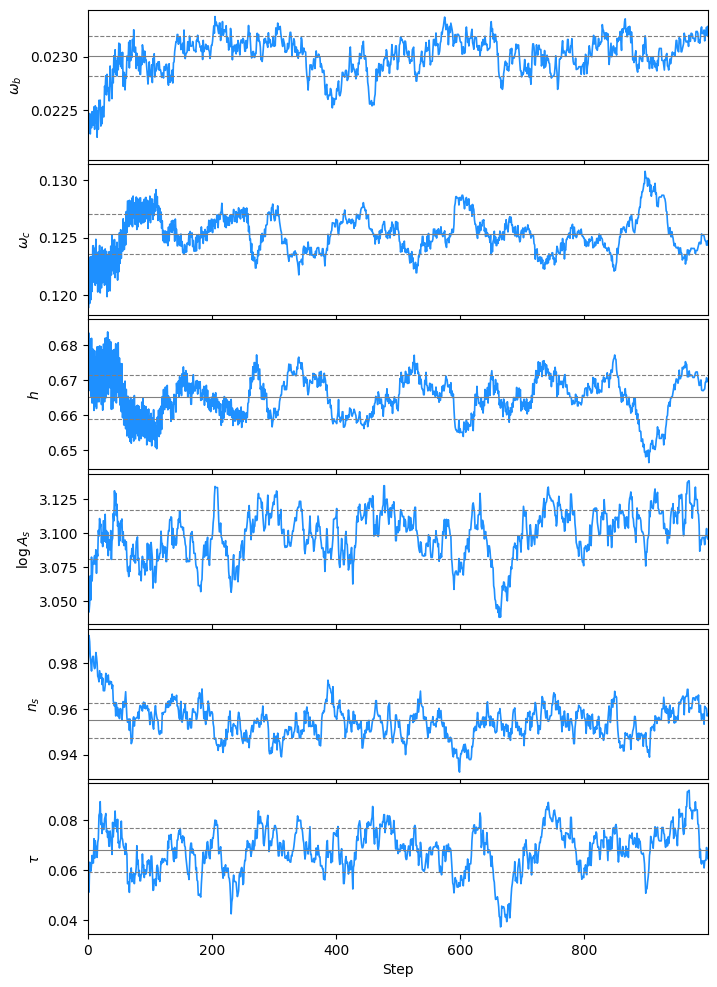

In [18]:
params_toplot = [ "ombh2", "omch2", "h", "logA", "ns", "tau" ]
labels = [r"\omega_b", r"\omega_c", r"h", r"\log A_s", r"n_s", r"\tau"]

fig, axes = plt.subplots(len(params_toplot), 1, figsize=(8, 12), sharex=True, gridspec_kw={"hspace":0.03})

for i, par in enumerate(params_toplot):
    ax = axes[i]
    ax.set_ylabel(f"${labels[i]}$")

    ix = parameters_baseline.index(par)
    ax.plot(samples[:,ix], lw=1.2, c="dodgerblue")
    ax.axhline(samples[:,ix].mean(), c="grey", lw=0.8)
    ax.axhline(samples[:,ix].mean() - samples[:,ix].std(), c="grey", lw=0.8, ls="--")
    ax.axhline(samples[:,ix].mean() + samples[:,ix].std(), c="grey", lw=0.8, ls="--")

axes[-1].set_xlim(0, samples.shape[0]-1)
axes[-1].set_xlabel(r"Step");

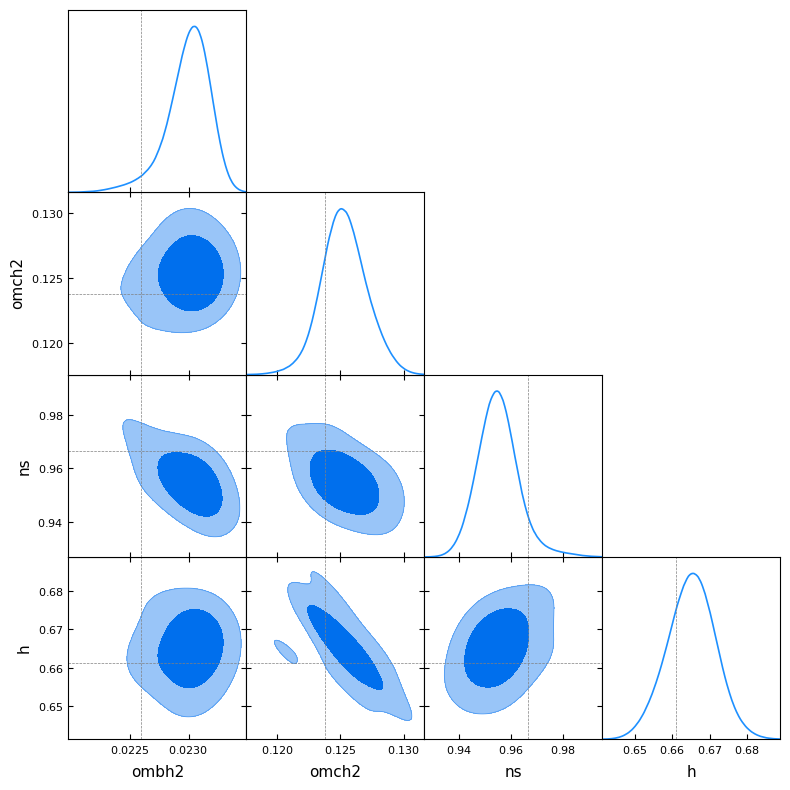

In [19]:
louis_means = {
    "ombh2": 2.259e-2,
    "omch2": 12.38e-2,
    "h": 0.6611,
    "ns": 0.9666
}

g = plots.get_subplot_plotter()
g.triangle_plot([chain], ["ombh2", "omch2", "ns", "h"], filled=True, color="dodgerblue", line_args=[{"lw":1.2, "color":"dodgerblue"}], markers=louis_means)
g.export("cosmology.png");

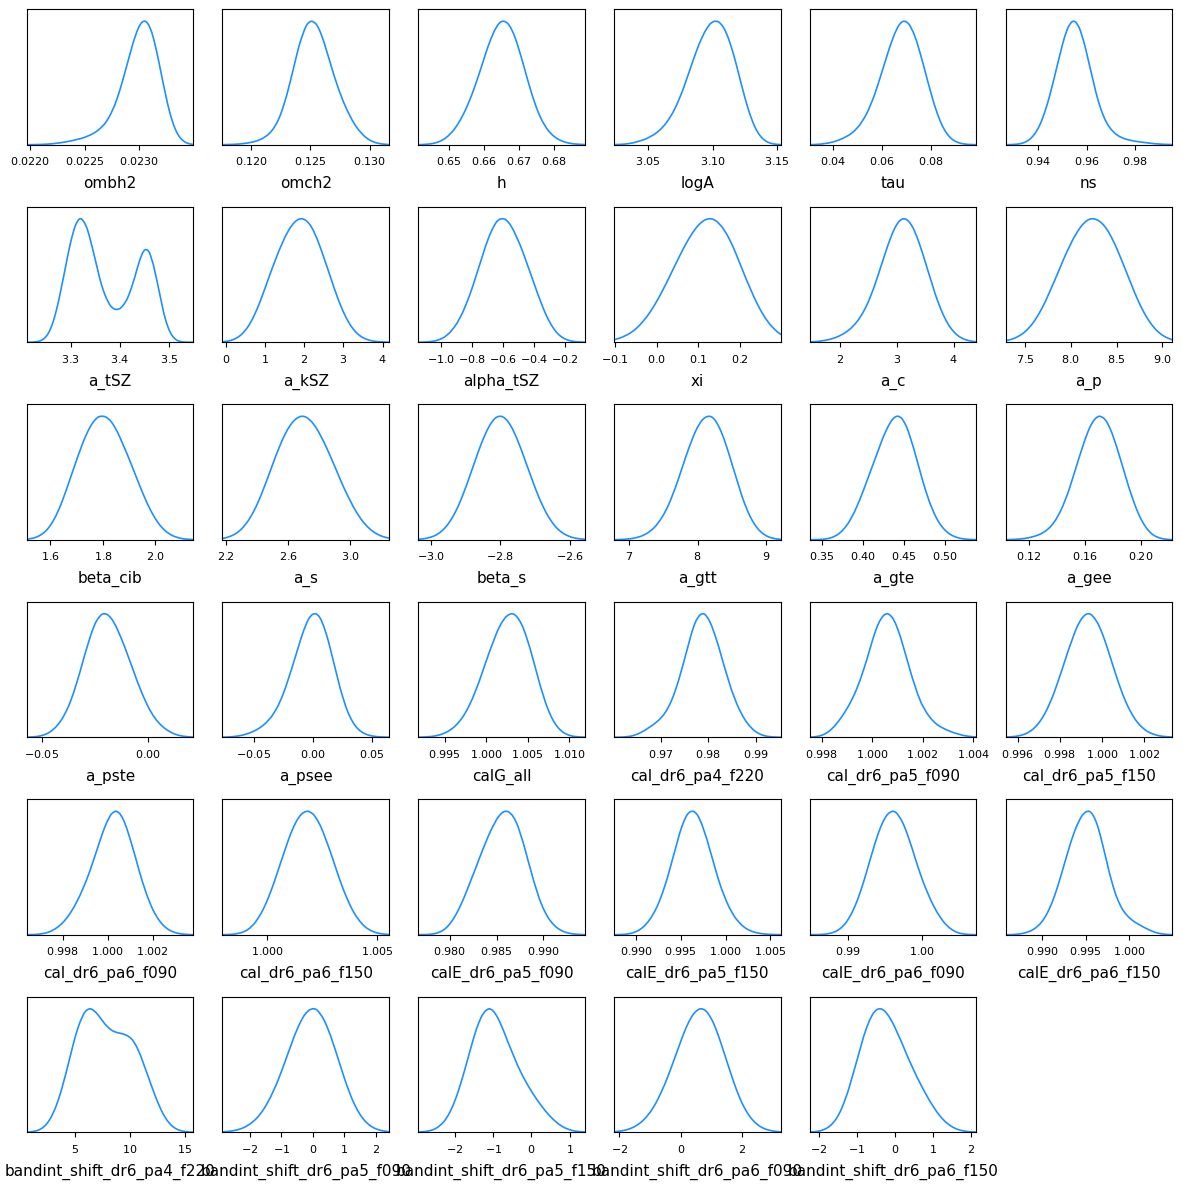

In [20]:
g = plots.get_subplot_plotter()
g.plots_1d([chain], parameters_baseline, nx = 6, line_args=[{"color":"dodgerblue", "lw":1.2}]);

In [ ]:
def inference_loop_multi_chain(rng, kernel, initial_state, num_samples, num_chains):
    @jax.jit
    def one_step(states, rng):
        keys = jrd.split(rng, num_chains)
        states, _ = jax.vmap(kernel)(keys, states)
        return states, states

    keys = jrd.split(rng, num_samples)
    _, states = jax.lax.scan(one_step, initial_state, keys)
    return states

logpost_norm = lambda theta_norm: logpost_baseline(norm_to_params(theta_norm))

rng = jrd.key(int(datetime.date.today().strftime("%Y%m%d")))

num_chains = 4
hmc = blackjax.hmc(logpost_norm, step_size=0.1, inverse_mass_matrix=jnp.eye(len(theta_baseline)), num_integration_steps=5)
initial_states = np.zeros((num_chains, len(theta_baseline)))
initial_states = jax.vmap(hmc.init, in_axes=(0))(initial_states)

states = inference_loop_multi_chain(rng, jax.jit(hmc.step), initial_states, 1000, num_chains)

samples = np.array(states.position)

In [ ]:
chains = []
logpost = []
for i in range(num_chains):
    chains.append(np.array(jax.vmap(norm_to_params)(samples[:,i,:])))
    logpost.append(-np.array(jax.vmap(logpost_baseline)(samples[:,i,:])))

chain = MCSamples(samples=chains, names=parameters_baseline, loglikes=logpost)

In [ ]:
params_toplot = [ "ombh2", "omch2", "h", "logA", "ns", "tau" ]
labels = [r"\omega_b", r"\omega_c", r"h", r"\log A_s", r"n_s", r"\tau"]

fig, axes = plt.subplots(len(params_toplot), 1, figsize=(8, 12), sharex=True, gridspec_kw={"hspace":0.03})

full_chain = np.array(chains)

for i, par in enumerate(params_toplot):
    ax = axes[i]
    ax.set_ylabel(f"${labels[i]}$")

    ix = parameters_baseline.index(par)
    for i in range(num_chains):
        ax.plot(full_chain[i,:,ix], lw=0.8, c=f"C{i}")
    ax.axhline(full_chain[:,:,ix].mean(), c="grey", lw=0.8)
    ax.axhline(full_chain[:,:,ix].mean() - full_chain[:,:,ix].std(), c="grey", lw=0.8, ls="--")
    ax.axhline(full_chain[:,:,ix].mean() + full_chain[:,:,ix].std(), c="grey", lw=0.8, ls="--")

axes[-1].set_xlim(0, full_chain.shape[1]-1)
axes[-1].set_xlabel(r"Step");

In [ ]:
louis_means = {
    "ombh2": 2.259e-2,
    "omch2": 12.38e-2,
    "h": 0.6611,
    "ns": 0.9666
}

g = plots.get_subplot_plotter()
g.triangle_plot([chain], ["ombh2", "omch2", "ns", "h"], filled=True, color="dodgerblue", line_args=[{"lw":1.2, "color":"dodgerblue"}], markers=louis_means)
g.export("cosmology.png");